# **Error Analysis - Video Games**


## 0. Setup 
Note: the predictions get retourned as BPR loss. As consequence, the predictions are not in the range of 0 to 1. To interpret them further, we need to convert them to the range of 0 to 1. Use sigmoid function.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
import itertools
from collections import defaultdict
import Levenshtein
# collect unique values from a dataframe

# from kgil utils import metrics
import sys

import sys
sys.path.append('../../')  # Add parent directory to path to find models package
from models.KGIL.utils.metrics import calc_cosine_similarity_fixed, gini_coefficient

from utils.data_processing import Visualize_KG, Process_KG


In [2]:
DATASET = "amazon-Video_Games"
EXPERIMENT_NAME = "#3 COL-Summary Step"
MODEL_TECHNIQUE_NAME = "gemma3"

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

REDUNDANCY_STRATEGIES = ["only-summary","wo-grand-parents"]
N_HOPS = ["3","6","9","11"]

relevant_metrics = ["NDCG@20","Recall@20","Precision@20","Hit_Ratio@20"]
relevant_metrics_df = pd.DataFrame()
metrics_df = pd.DataFrame()
for REDUNDANCY_STRATEGY in REDUNDANCY_STRATEGIES:
    METRICS_PATH = os.path.join(project_root, 'data','experiments',EXPERIMENT_NAME,DATASET,REDUNDANCY_STRATEGY)
    for N_HOP in N_HOPS:
        n_hops_metrics_df = pd.read_csv(f"{METRICS_PATH}/{N_HOP}-Hops_acc_df.csv")
        n_hops_metrics_df["redundancy_strategy"] = REDUNDANCY_STRATEGY
        n_hops_metrics_df["n_hops"] = N_HOP
        metrics_df = pd.concat([metrics_df, n_hops_metrics_df], ignore_index=True)

        for METRIC in relevant_metrics:
            temp_df = metrics_df[metrics_df["Metric"] == METRIC]
            relevant_metrics_df = pd.concat([relevant_metrics_df, temp_df], ignore_index=True)

TAXONOMY_PATH = os.path.join(project_root, "data","taxonomy",DATASET)

gemma_taxonomy_baseline = pd.read_csv(f"{TAXONOMY_PATH}/gemma3_taxonomy-wo-grand-parents.csv")
gemma_taxonomy_only_summary = pd.read_csv(f"{TAXONOMY_PATH}/gemma3_taxonomy-summarized.csv")
gemma_taxonomy_wo_grand_parents_summary = pd.read_csv(f"{TAXONOMY_PATH}/gemma3_taxonomy-wo-grand-parents_summarized.csv")


## Qualitative Analysis
Investigate the impact of taxonomic summarization on structural properties and semantic coherence through comparative visualization


Issue 1: Semantic Drift in LLM Task Goal
- The LLM lost task context during taxonomy generation, potentially leading to:
    - Limited/low coverage of taxonomy from product description keywords
    - LLM began explanatory behavior rather than taxonomic organization
- Likely caused by high context windows of taxonomy and from keyword batches
    - Resulted in redundant deep taxonomy with duplicates at lower levels

 Issue 2: Popularity Bias
 Analysis revealed:
 - High concentration of items
 - Strong bias towards first-level parent connections

 Proposed Solution: Summary Step Integration
 Strategy: Incorporate summary step in batch-wise multi-step LLM reasoning
 Benefits:
 - Summarizes redundant taxonomy levels
 - Reduces context window size of taxonomy
    - Helps prevent semantic drift
    - Maintains task focus
        - Enables comprehensive keyword coverage
        - Improves overall taxonomy coverage


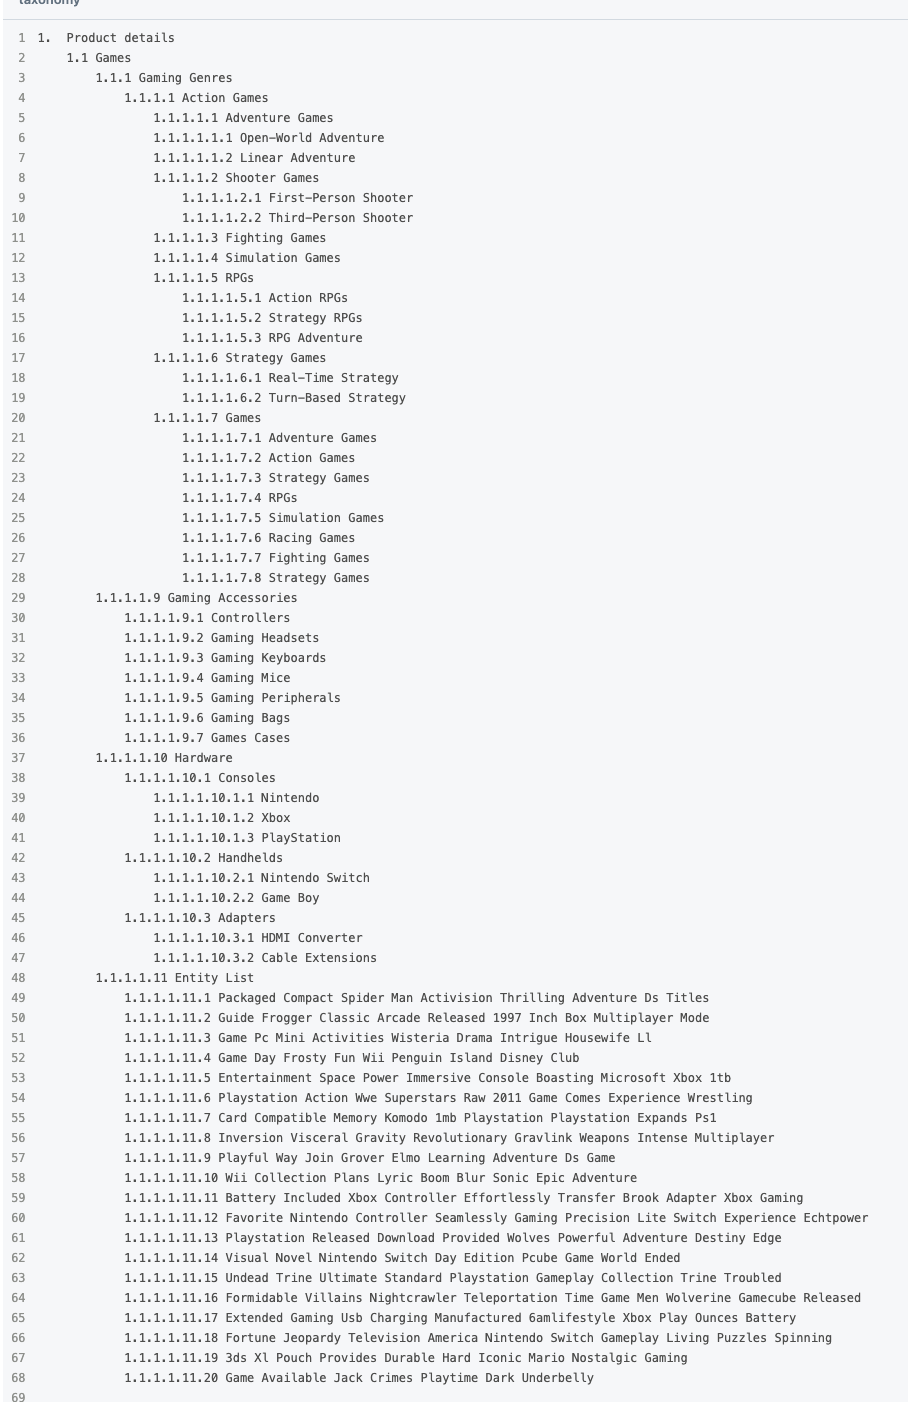

In [3]:
from IPython.display import Image
Image(filename="/Users/U725801/Desktop/Masterarbeit/Abbildungen/complete taxonomy summarized.png")

In the picture below the complete taxonomy with the summary step is visualized.  Additionally it didnt prevent the LLM task loose looking at this [Trace](https://dagshub.com/jonas.limniatis2/LLM-Col.mlflow/#/experiments/6/runs/4030be0c2a9a4e299638bcc4783d8f5d/traces?selectedTraceId=7bde4e184ee54de590214dab8162814e).

**Impact**
- summary step leads to a more detailed taxonomy with more fine granular categories and less coarse categories. 
    - contrary to assumptions
- because of deep taxonomy still large context window
    - consequence is again loss of taxonomy during batch process
    - coverage issue remains unsolved    
- llm still hallucinates
    - example: Subgraph of _1.1.1.1.11 Entity List_ seems to hallucinated. It seems to containing short game descriptions. For instance _Game Pc Mini Activities Wisteria Drama Intrigue Housewife Ll_. 
    - didnt generalized or organized entitys accurately, just copied more or less entitys to a parent entity list.

**Conclusion**
We can see that almost no hypothesis, like prevent of semantic drift /task loss, coarse-granular taxonomy nor prevention of hallucination could be by integration the summary step accepted. 



In [4]:
gemma_relation_wo_products_only_summary = gemma_taxonomy_only_summary[
    (~gemma_taxonomy_only_summary["head"].str.startswith("B0")) &
    (~gemma_taxonomy_only_summary["head"].str.startswith("A")) &
    (~gemma_taxonomy_only_summary["head"].str.match(r'^\d'))
]

In [5]:
gemma_relation_wo_products_only_summary.head()

,Unnamed: 0,head,relation,tail
0,0,Product details,is parent of,Games
1,1,Games,is parent of,Gaming Genres
2,2,Gaming Genres,is parent of,Action Games
7,7,Shooter Games,is parent of,First-Person Shooter
8,8,Shooter Games,is parent of,Third-Person Shooter


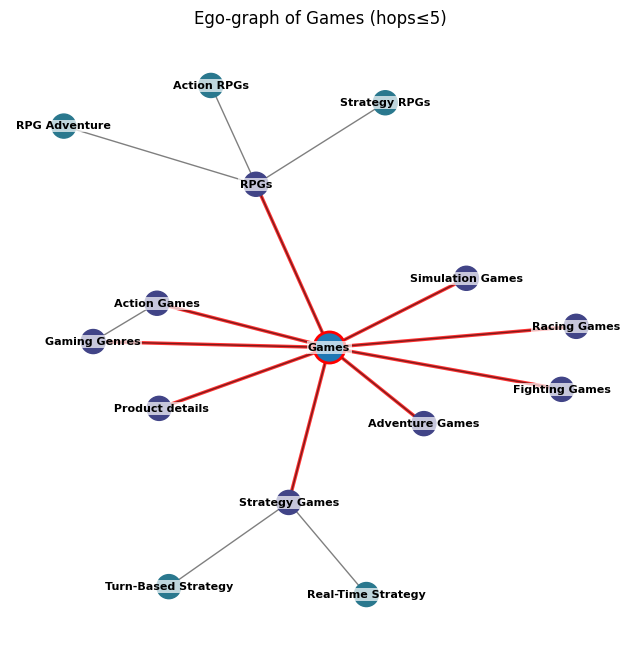

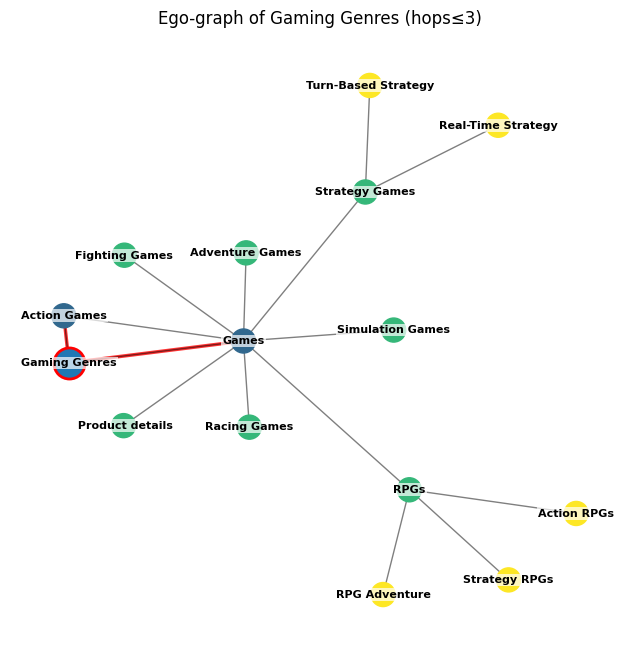

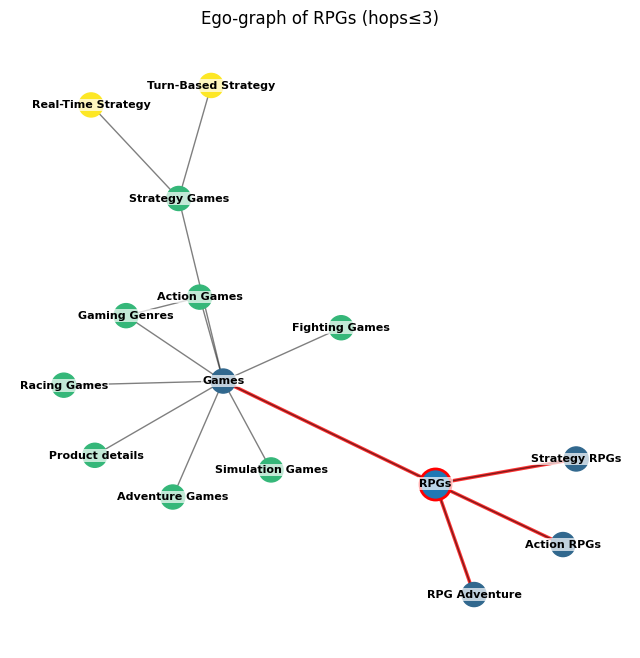

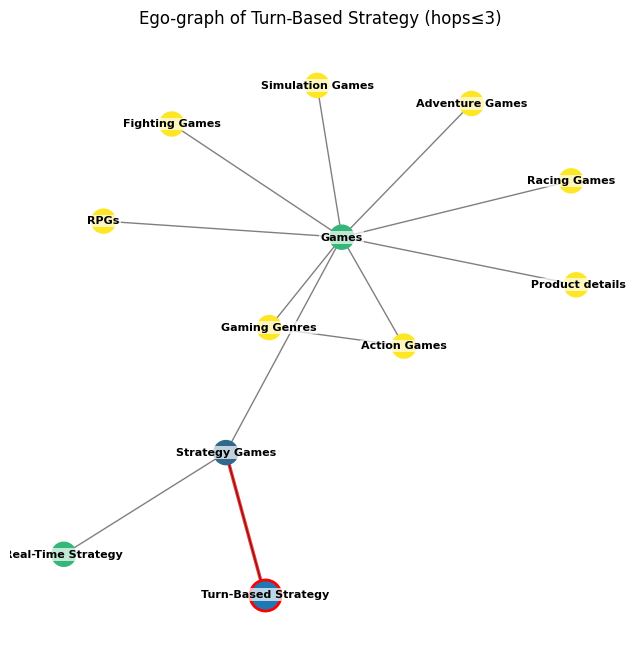

In [6]:
viz = Visualize_KG()
g_taxonomy_only_summary = nx.from_pandas_edgelist(gemma_relation_wo_products_only_summary, source='head', target='tail')
viz.draw_ego_hops(g_taxonomy_only_summary,"Games",hops=5)
viz.draw_ego_hops(g_taxonomy_only_summary,"Gaming Genres",hops=3)
viz.draw_ego_hops(g_taxonomy_only_summary,"RPGs",hops=3)
viz.draw_ego_hops(g_taxonomy_only_summary,"Turn-Based Strategy",hops=3)

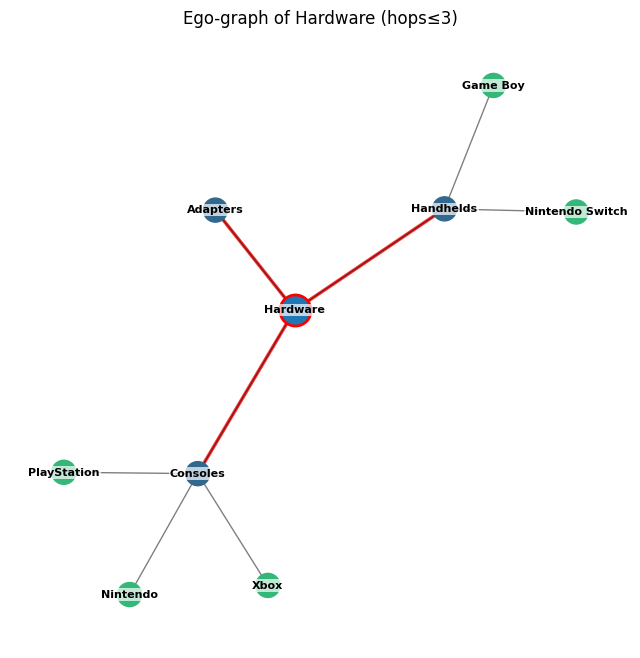

In [7]:
viz.draw_ego_hops(g_taxonomy_only_summary,"Hardware",hops=3)

In [15]:
# calc degree centrality for g_tax_summary
g_tax_summary = nx.from_pandas_edgelist(gemma_taxonomy_only_summary, source='head', target='tail')
centrality = nx.degree_centrality(g_tax_summary)
dict(sorted(centrality.items(), key=lambda item: item[1], reverse=True))

{'Games': 0.6192550642561534,
 'Consoles': 0.5286429971683729,
 'Shooter Games': 0.4972772816379874,
 'Nintendo': 0.49705946416902635,
 'Action Games': 0.4375952951426705,
 'Adventure Games': 0.43302112829448924,
 'PlayStation': 0.4323676758876062,
 'Fighting Games': 0.3702896972337182,
 'RPGs': 0.3546068394685254,
 'Games Cases': 0.3286865606621651,
 'Gaming Accessories': 0.3278152907863211,
 'Xbox': 0.325637116096711,
 'RPG Adventure': 0.29427140056632545,
 'Gaming Genres': 0.2879546939664561,
 'Strategy Games': 0.264866042256589,
 'Game Boy': 0.2548464386843825,
 'Action RPGs': 0.24330211282944894,
 'Simulation Games': 0.2345894140710085,
 'Nintendo Switch': 0.2300152472228273,
 'Gaming Peripherals': 0.21367893705075147,
 'Gaming Mice': 0.20496623829231106,
 'Strategy RPGs': 0.20365933347854498,
 'Gaming Keyboards': 0.13352210847309956,
 'Racing Games': 0.1241559573077761,
 'Controllers': 0.10019603572206491,
 'Linear Adventure': 0.0980178610324548,
 'Gaming Bags': 0.098017861032454

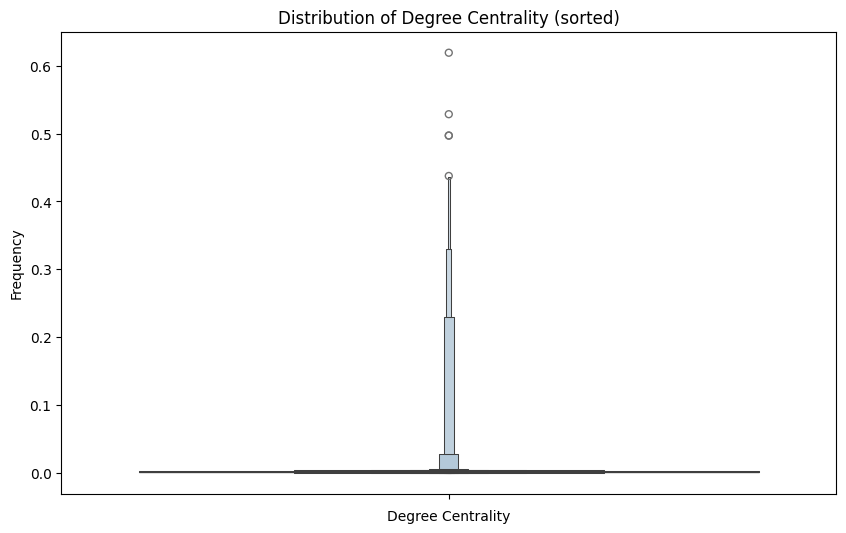

In [19]:
# Get sorted degree centrality values
centrality_values = sorted(centrality.values(), reverse=True)

plt.figure(figsize=(10,6))
sns.boxenplot(centrality_values)
plt.title("Distribution of Degree Centrality (sorted)")
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.show()

In [20]:
# calc degree centrality for g_tax_summary
g_tax_wo_products_summary = nx.from_pandas_edgelist(gemma_taxonomy_wo_grand_parents_summary, source='head', target='tail')
centrality = nx.degree_centrality(g_tax_wo_products_summary)
dict(sorted(centrality.items(), key=lambda item: item[1], reverse=True))

{'Consoles': 0.326955074875208,
 'Games': 0.2753743760399335,
 'Nintendo Switch': 0.17803660565723795,
 'Nintendo': 0.10440931780366057,
 'Adventure Games': 0.09359400998336107,
 'RPG Adventure': 0.07778702163061564,
 'Fighting Games': 0.07321131447587355,
 'Favorite Nintendo Controller Seamlessly Gaming Precision Lite Switch Experience Echtpower': 0.07113144758735442,
 'Controllers': 0.06530782029950083,
 'Gaming Accessories': 0.059900166389351084,
 'Action Games': 0.05324459234608985,
 'Fortune Jeopardy Television America Nintendo Switch Gameplay Living Puzzles Spinning': 0.03993344425956739,
 'Playstation Released Download Provided Wolves Powerful Adventure Destiny Edge': 0.03868552412645591,
 'Gaming Peripherals': 0.03826955074875208,
 'Card Compatible Memory Komodo 1mb Playstation Playstation Expands Ps1': 0.03161397670549085,
 'Entertainment Space Power Immersive Console Boasting Microsoft Xbox 1tb': 0.027870216306156406,
 'Game Day Frosty Fun Wii Penguin Island Disney Club': 0.0

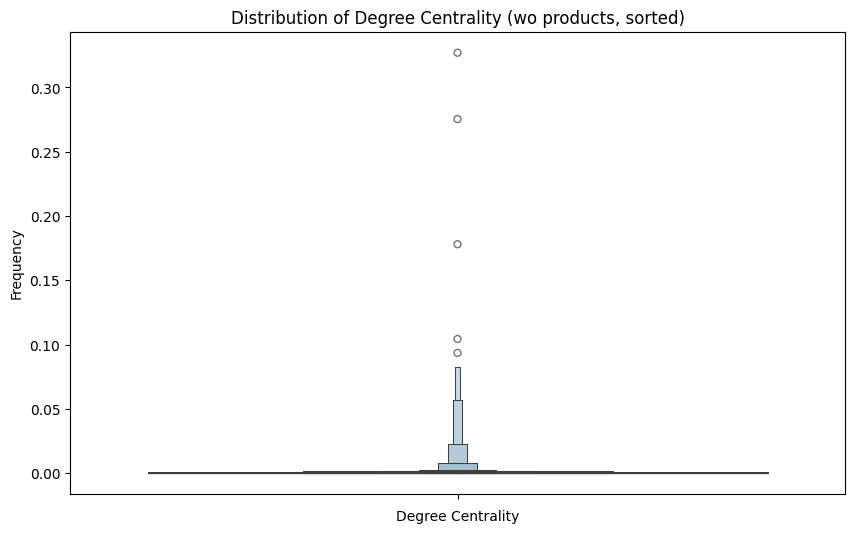

In [21]:
# Plot a boxenplot of the degree centrality values for g_tax_wo_products_summary

centrality_values_wo_products = sorted(centrality.values(), reverse=True)

plt.figure(figsize=(10,6))
sns.boxenplot(centrality_values_wo_products)
plt.title("Distribution of Degree Centrality (wo products, sorted)")
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")
plt.show()


The degree centrality for the generated and linked taxonomy with the summary step is broader, with generally higher centrality values. When redundant links to (greater) grand-parent entities are removed, the knowledge graph becomes less centralized and its degree centrality distribution is more right-skewed. This indicates that the redundancy removal strategy helps the recommendation process, likely because the centrality of the knowledge graph decreases—there are fewer hubs and more distinct paths, making the structure less dominated by top-level entities.

Analysis of Taxonomy Structure Changes After COL-Summary Step

The visualization of the taxonomy reveals significant structural differences between the baseline and COL-Summary approaches:

1. **Baseline Taxonomy Characteristics:**
   - Strong hierarchical focus on gaming platforms/consoles (e.g., XBOX, PlayStation)
   - Detailed breakdown from platform level to specific game categories
   - Example: XBOX → XBOX Games → Specific Game Genres

2. **COL-Summary Taxonomy Characteristics:**
   - Reduced emphasis on console/platform hierarchy while maintaining hardware presence
   - More fine-grained categorization (e.g., RPGs → Action RPGs)

3. **Potential Causes:**
   - The summary step didnt prevent the LLM to lose context about the original task because of the large context windows. 
        + This hints the number of Keywords from the batch for each step might lead to the overflow not the taxonomy itself.
        + Additionally promotes incompleteness of the taxonomy.
   - The LLM reconstructed after the loss of task context the taxonomy rather than summarizing the existing one
   - Despite LLM traces showing summarization attempts, the resulting taxonomy shows significant structural changes

4. **Implications:**
   - The summary step appears to have fundamentally altered the taxonomy's focus making it take more categories into account and fine-grained categorization them.
   - The resulting taxonomy is more detailed and less coarse.
   - The fine-grained categorization might affect the precision of recommendations or classifications

This analysis suggests that the COL-Summary step, while intended to simplify the taxonomy, may have inadvertently caused the LLM to deviate from the original task structure, resulting in a fundamentally different taxonomy organization.


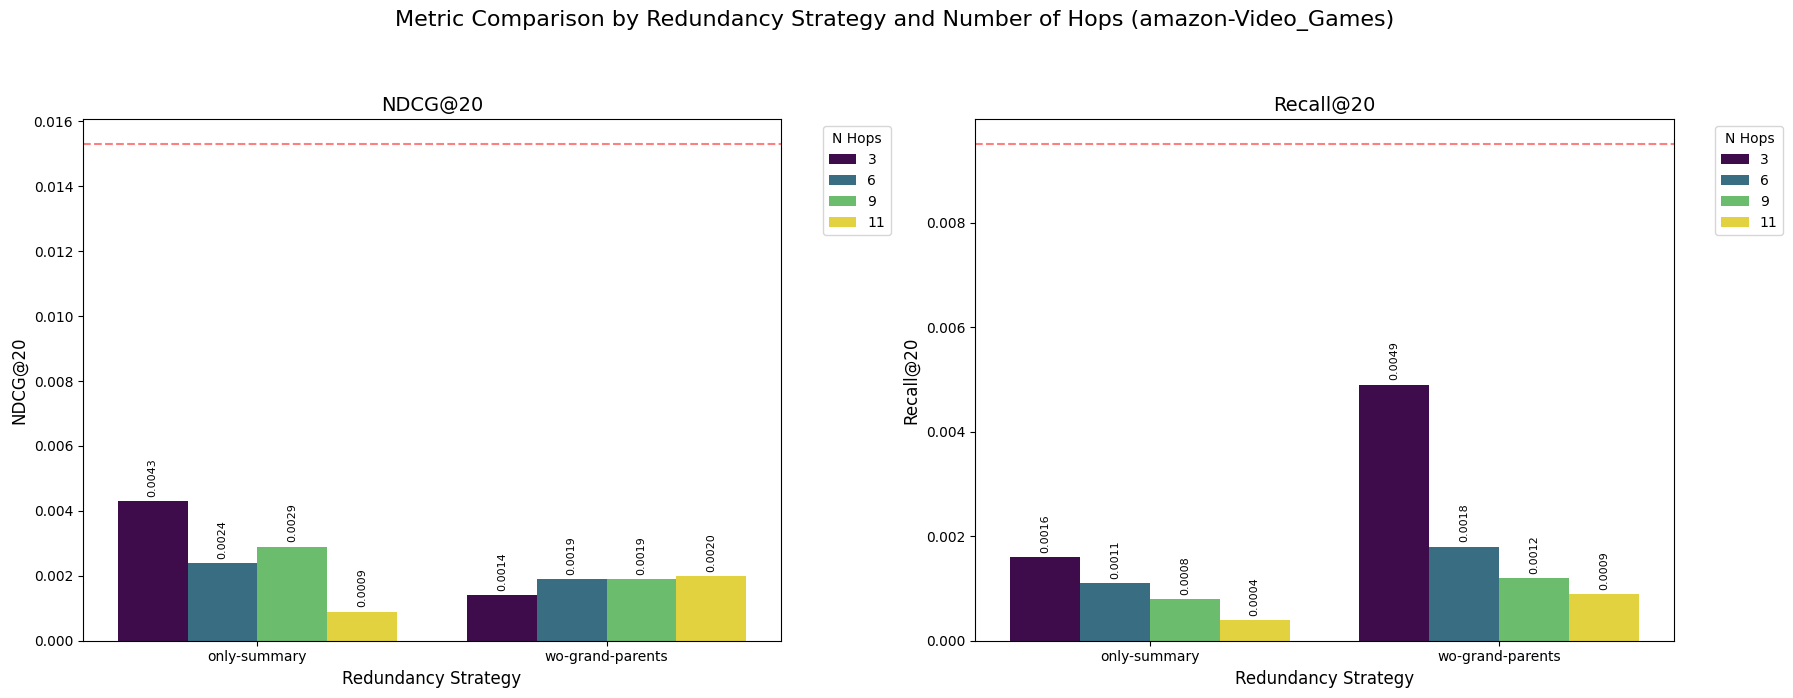

In [9]:
relevant_metrics_df['n_hops'] = pd.to_numeric(relevant_metrics_df['n_hops'])

strategies = relevant_metrics_df['redundancy_strategy'].unique() # This variable is defined but not used later in this cell for plotting order.
n_hops_order = sorted(relevant_metrics_df['n_hops'].unique())

strategy_order = REDUNDANCY_STRATEGIES

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7)) 

fig.suptitle(f'Metric Comparison by Redundancy Strategy and Number of Hops ({DATASET})', fontsize=16, y=1.02) 

ax1 = axes[0]
hr_df = relevant_metrics_df[relevant_metrics_df['Metric'] == 'NDCG@20']
sns.barplot(data=hr_df, x='redundancy_strategy', y='Value', hue='n_hops', ax=ax1, palette='viridis', hue_order=n_hops_order, order=strategy_order)
ax1.set_xlabel('Redundancy Strategy', fontsize=12)
ax1.set_ylabel('NDCG@20', fontsize=12)
ax1.set_title('NDCG@20', fontsize=14)
ax1.tick_params(axis='x', rotation=0, labelsize=10) # Consider adjusting rotation if strategy names overlap
ax1.tick_params(axis='y', labelsize=10)
ax1.legend(title='N Hops', bbox_to_anchor=(1.05, 1), loc='upper left') 

# Add horizontal line for NDCG@20 baseline
ax1.axhline(y=0.0153, color='r', linestyle='--', alpha=0.5, label='Baseline Collaborative Filtering')

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', fontsize=8, padding=3, rotation=90) 

ax2 = axes[1]
pr_df = relevant_metrics_df[relevant_metrics_df['Metric'] == 'Recall@20']
sns.barplot(data=pr_df, x='redundancy_strategy', y='Value', hue='n_hops', ax=ax2, palette='viridis', hue_order=n_hops_order, order=strategy_order)
ax2.set_xlabel('Redundancy Strategy', fontsize=12)
ax2.set_ylabel('Recall@20', fontsize=12)
ax2.set_title('Recall@20', fontsize=14)
ax2.tick_params(axis='x', rotation=0, labelsize=10) # Consider adjusting rotation if strategy names overlap
ax2.tick_params(axis='y', labelsize=10)
ax2.legend(title='N Hops', bbox_to_anchor=(1.05, 1), loc='upper left') 

# Add horizontal line for Recall@20 baseline
ax2.axhline(y=0.0095, color='r', linestyle='--', alpha=0.5, label='Baseline Collaborative Filtering')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', fontsize=8, padding=3, rotation=90) 

fig.tight_layout(rect=[0, 0.03, 1, 0.97]) 

plt.show()

plt.rcParams['figure.figsize'] = [18, 10] 


In [30]:
# Load results from experiment 1 for best performing n_hops
N_HOP_EXPERIMENT_2 = 6
EXPERIMENT_2_PATH = os.path.join(project_root, "data","experiments","#2 Taxonomy without redundancies",DATASET)
EXPERIMENT_3_PATH = os.path.join(project_root, "data","experiments","#3 COL-Summary Step",DATASET)
N_HOP_ONLY_SUMMARY = 3
N_HOP_WO_GRAND_PARENTS = 3


STRATEGY_ONLY_SUMMARY = "only-summary"
STRATEGY_WO_GRAND_PARENTS = "wo-grand-parents"

EXPERIMENT_2_STRATEGY = "wo-grand-parents"
experiment_2_metrics = pd.read_csv(f"{EXPERIMENT_2_PATH}/{MODEL_TECHNIQUE_NAME}/{EXPERIMENT_2_STRATEGY}/{N_HOP_EXPERIMENT_2}-Hops_acc_df.csv")


# Get baseline metrics from experiment 1
baseline_ndcg = experiment_2_metrics[experiment_2_metrics['Metric'] == 'NDCG@20']['Value'].iloc[0]
baseline_recall = experiment_2_metrics[experiment_2_metrics['Metric'] == 'Recall@20']['Value'].iloc[0]
baseline_hit_ratio = experiment_2_metrics[experiment_2_metrics['Metric'] == 'Hit_Ratio@20']['Value'].iloc[0]
baseline_precision = experiment_2_metrics[experiment_2_metrics['Metric'] == 'Precision@20']['Value'].iloc[0]

# Load experiment 2 metrics for each strategy
strategies = ['only-summary', 'wo-grand-parents']

for strategy in strategies:
    if strategy == "only-summary":
        N_HOPS = N_HOP_ONLY_SUMMARY
    elif strategy == "wo-grand-parents":
        N_HOPS = N_HOP_WO_GRAND_PARENTS

    if strategy == STRATEGY_ONLY_SUMMARY:
        exp3_metrics = pd.read_csv(f"{EXPERIMENT_3_PATH}/{strategy}/{N_HOPS}-Hops_acc_df.csv")
    else:
        exp3_metrics = pd.read_csv(f"{EXPERIMENT_3_PATH}/{strategy}/{N_HOPS}-Hops_acc_df.csv")

    
    # Get metrics for current strategy
    strategy_ndcg = exp3_metrics[exp3_metrics['Metric'] == 'NDCG@20']['Value'].iloc[0]
    strategy_recall = exp3_metrics[exp3_metrics['Metric'] == 'Recall@20']['Value'].iloc[0]
    strategy_hit_ratio = exp3_metrics[exp3_metrics['Metric'] == 'Hit_Ratio@20']['Value'].iloc[0]
    strategy_precision = exp3_metrics[exp3_metrics['Metric'] == 'Precision@20']['Value'].iloc[0]
    
    # Calculate percentage changes
    ndcg_delta = ((strategy_ndcg - baseline_ndcg) / baseline_ndcg) * 100
    recall_delta = ((strategy_recall - baseline_recall) / baseline_recall) * 100

    hit_ratio_delta = ((strategy_hit_ratio - baseline_hit_ratio) / baseline_hit_ratio) * 100
    precision_delta = ((strategy_precision - baseline_precision) / baseline_precision) * 100
    
    # Print results
    print(f"\nResults for {strategy} (n_hops={N_HOPS}):")
    print(f"NDCG@20: {strategy_ndcg:.4f} (LLM-COL-Hierarchy-Tax-wo-grand-parents: {baseline_ndcg:.4f}, delta: {ndcg_delta:+.2f}%)")
    print(f"Recall@20: {strategy_recall:.4f} (LLM-COL-Hierarchy-Tax-wo-grand-parents: {baseline_recall:.4f}, delta: {recall_delta:+.2f}%)")
    print(f"Hit_Ratio@20: {strategy_hit_ratio:.4f} (LLM-COL-Hierarchy-Tax-wo-grand-parents: {baseline_hit_ratio:.4f}, delta: {hit_ratio_delta:+.2f}%)")
    print(f"Precision@20: {strategy_precision:.4f} (LLM-COL-Hierarchy-Tax-wo-grand-parents: {baseline_precision:.4f}, delta: {precision_delta:+.2f}%)")



Results for only-summary (n_hops=3):
NDCG@20: 0.0043 (LLM-COL-Hierarchy-Tax-wo-grand-parents: 0.0176, delta: -75.57%)
Recall@20: 0.0016 (LLM-COL-Hierarchy-Tax-wo-grand-parents: 0.0369, delta: -95.66%)
Hit_Ratio@20: 0.0111 (LLM-COL-Hierarchy-Tax-wo-grand-parents: 0.0738, delta: -84.96%)
Precision@20: 0.0006 (LLM-COL-Hierarchy-Tax-wo-grand-parents: 0.0037, delta: -83.78%)

Results for wo-grand-parents (n_hops=3):
NDCG@20: 0.0014 (LLM-COL-Hierarchy-Tax-wo-grand-parents: 0.0176, delta: -92.05%)
Recall@20: 0.0049 (LLM-COL-Hierarchy-Tax-wo-grand-parents: 0.0369, delta: -86.72%)
Hit_Ratio@20: 0.0049 (LLM-COL-Hierarchy-Tax-wo-grand-parents: 0.0738, delta: -93.36%)
Precision@20: 0.0002 (LLM-COL-Hierarchy-Tax-wo-grand-parents: 0.0037, delta: -94.59%)


The results show a notable decrease in performance metrics when comparing the baseline LLM-Col-Hierarchy-Tax-wo-grand-parents (NDCG@20: 0.0113, Recall@20: 0.0053) against variations that incorporate the summary step and removal of redundant relationships from items to grand-parents (NDCG@20: 0.0014, Recall@20: 0.0049). 

The degradation in performance metrics suggests that the fine-grained hierarchical relationships at end of taxonomy generation process presented in the original taxonomy may actually provide valuable discriminative power for capturing user preferences. While the summary step simplifies the taxonomy structure, it appears to remove some of the nuanced category distinctions that help the model better understand and predict user interests.

This finding aligns with the hypothesis that more detailed category relationships, even if they create a more complex taxonomy structure, can be beneficial for recommendation quality. The original taxonomy's ability to capture subtle category distinctions may be more important than the theoretical benefits of a simplified, flatter structure. Additionally, we observe that the optimal number of hops has shifted from 6 to 3 with the integrated summary step, suggesting that the flattened structure requires less propagation depth to capture relevant relationships.


In [11]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
cos_sim_baseline_only_summary = calc_cosine_similarity_fixed(gemma_taxonomy_baseline, gemma_taxonomy_only_summary, embedding_model)
cos_sim_baseline_wo_direct_parents_summary = calc_cosine_similarity_fixed(gemma_taxonomy_baseline, gemma_taxonomy_wo_direct_parents_summary, embedding_model)
cos_sim_baseline_wo_grand_parents_summary = calc_cosine_similarity_fixed(gemma_taxonomy_baseline, gemma_taxonomy_wo_grand_parents_summary, embedding_model)

print(f"Cosine similarity between the original Taxonomy without summary nor direct links to grand parents and the summarized taxonomy: {cos_sim_baseline_only_summary:.3f}")
print(f"Cosine similarity between the original Taxonomy without summary nor direct links to grand parents and the summarized taxonomy without direct parents: {cos_sim_baseline_wo_direct_parents_summary:.3f}")
print(f"Cosine similarity between the original Taxonomy without summary nor direct links to grand parents and the summarized taxonomy without grand parents: {cos_sim_baseline_wo_grand_parents_summary:.3f}")



Cosine similarity between the original Taxonomy without summary nor direct links to grand parents and the summarized taxonomy: 0.300
Cosine similarity between the original Taxonomy without summary nor direct links to grand parents and the summarized taxonomy without direct parents: 0.300
Cosine similarity between the original Taxonomy without summary nor direct links to grand parents and the summarized taxonomy without grand parents: 0.300


The semantically cosine similarity of the baseline LLM-Col-Hierarchy-Tax wo-grand-parents taxonomy to the variations of the LLM-Col-Hierarchy-Tax, which used same LLM, keywords and an updated COL with a integrated summary step, is for all comparisons 30%. For several reason this is intresting. First we notice that the summary step actually impacts the taxonomy creation. Second looking at a results of this expeirment compared to the one of the first one we observe differences in best performances at 3 hops. Non the less the results of the summarized taxonomy was not able to outperform the baseline. Third we notice that for the summarized taxonomy the removal strategie wo-grand-parents performs worse than the summarized taxonomy without direct parents and only-summary. Indicating that removal of redundant item taxonomy entitiy links could be sensitive to the taxonomy depth or structure. 


To better understand the impact of the summary step on the taxonomy we can look at the distribution of the items to the first level parents and the graph of the taxonomy. 

In [12]:
MODEL_TECHNIQUE = "gemma3"
METADATA_PATH = os.path.join(project_root, 'data','preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'data','taxonomy',DATASET)
REDUNDANCY_STRATEGY = "only-summary"
N_HOP_ONLY_SUMMARY = 3

gemma_relation_summarized = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-summarized.csv")

# Load mapping
MAPPING_PATH = os.path.join(project_root, "data","experiments", EXPERIMENT_NAME, DATASET, MODEL_TECHNIQUE)
gemma_mapping = pd.read_csv(f"{MAPPING_PATH}/entity_map.csv")

df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set


print(f"Processing Strategy: {REDUNDANCY_STRATEGY}, Hops: {N_HOP_ONLY_SUMMARY}")
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
error_df = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/only-summary-{N_HOP_ONLY_SUMMARY}-Hops_predictions.csv")

error_df["user_id"] = error_df["user_id"].map(gemma_mapping.set_index("id")["entity"])
error_df["item_id"] = error_df["item_id"].map(gemma_mapping.set_index("id")["entity"])


process_kg = Process_KG()
error_df = process_kg.process_prediction(error_df)
error_df = process_kg.count_hits(error_df)
error_df['item_id'] = error_df['item_id'].astype(str)
error_df['user_id'] = error_df['user_id'].astype(str)

Processing Strategy: only-summary, Hops: 3
Accuracy in test set: 0.4215589250206827


As we performance metrics indiacte illustrated by the summarized taxonomy we see a decrease in true positives for the test set (4265 to 3080). Additionally the true positives for the top K prediction set (11) is lower than the baseline (28). This indicates that the summarized taxonomy is not able to capture the user preferences as well as the baseline. 

<Axes: ylabel='count'>

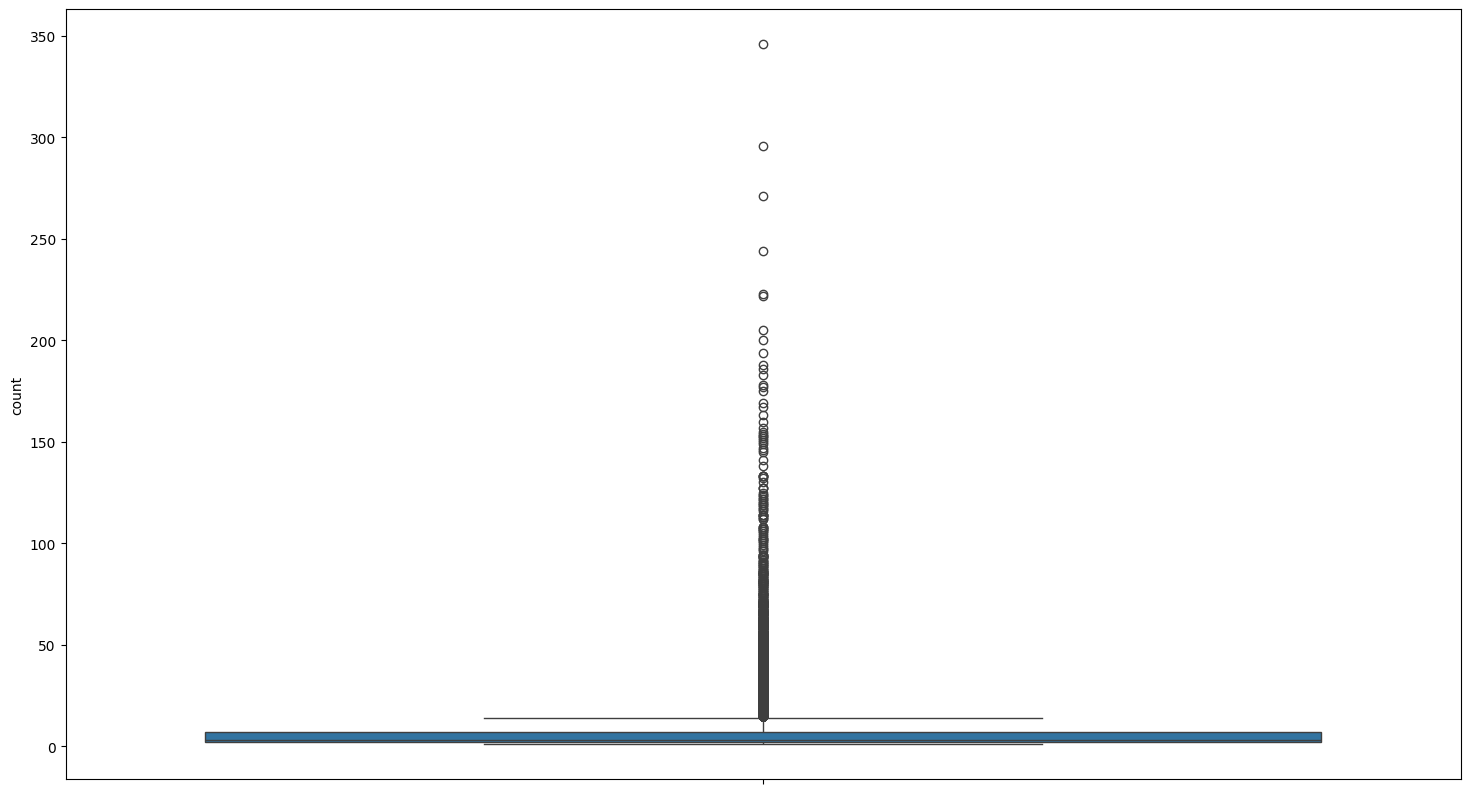

In [13]:
train_df = pd.read_csv("/Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/preprocessed/amazon-Video_Games/train_df.csv")
train_df["parent_asin"].value_counts().describe()
sns.boxplot(train_df["parent_asin"].value_counts())

we dont observe a tight distribtuion of parent_asins in train data. on average an item is 7 times in the train data. While the 50% quantile is at 3. Max is 346 indicating that some items are very popular. Non the less the distribubtion does not indicate a strong popularity bias. 

Summarized taxonomy distribution of items to first level parents in train and test set. We observe primarly first level parents due to fact n hops 3 shows best results. 

In [14]:
DATASET = "amazon-Video_Games"
MODEL_TECHNIQUE = "gemma3"

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#3 COL-Summary Step"
STRATEGY = "wo-grand-parents"
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments",EXPERIMENT_NAME,DATASET,STRATEGY)

METADATA_PATH = os.path.join(project_root, 'data','preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'data','taxonomy',DATASET)

prediction_error = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/3-Hops_predictions.csv")
entity_map = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
gemma_taxonomy_only_summary = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy-summarized.csv")
gemma_taxonomy = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy.csv")
df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set

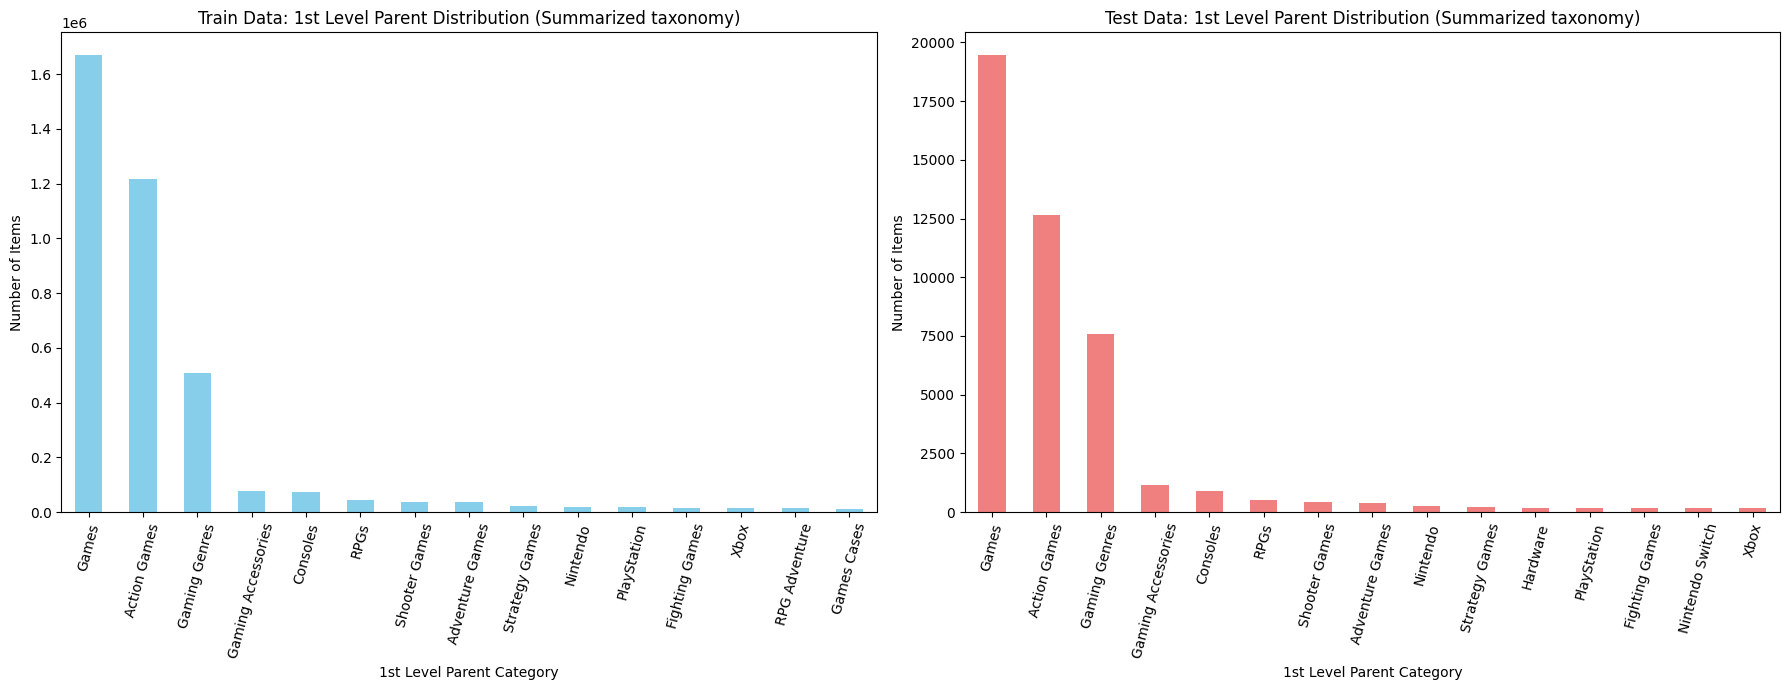

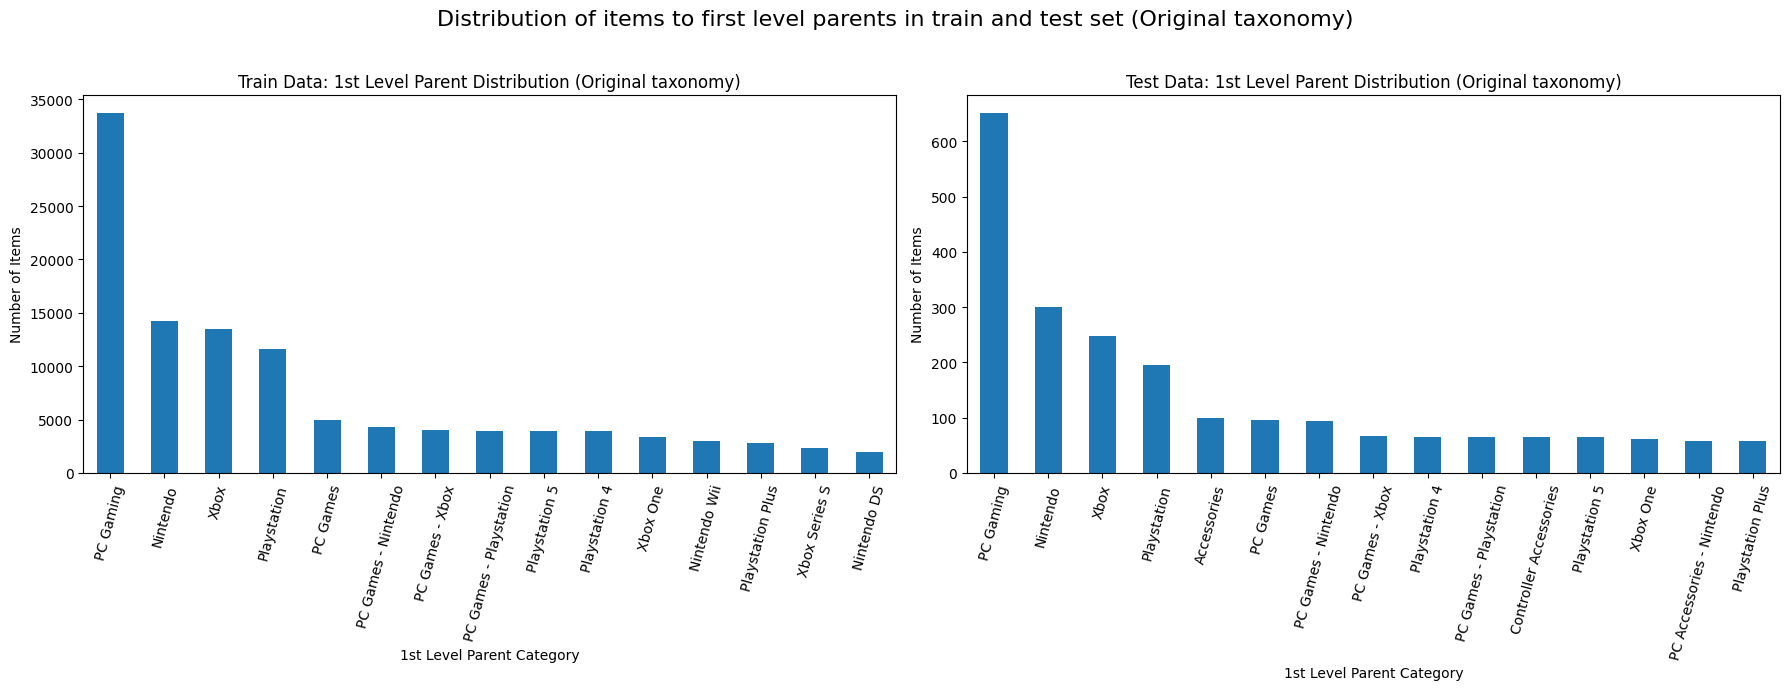

In [15]:
prediction_error["user_id"] = prediction_error["user_id"].map(entity_map.set_index("id")["entity"])
prediction_error["item_id"] = prediction_error["item_id"].map(entity_map.set_index("id")["entity"])

df_test["item_id"] = df_test["parent_asin"]
df_train["item_id"] = df_train["parent_asin"]

df_train_parents_summarized = process_kg.connect_parents(df_train, gemma_taxonomy_only_summary)
df_test_parents_summarized = process_kg.connect_parents(df_test, gemma_taxonomy_only_summary)
df_train_parents_original = process_kg.connect_parents(df_train, gemma_taxonomy)
df_test_parents_original = process_kg.connect_parents(df_test, gemma_taxonomy)

# Get value counts for 1st level parents in train and test sets, top 15
train_1st_level_parent_counts = df_train_parents_summarized['first_level_parent'].value_counts().head(15)
test_1st_level_parent_counts = df_test_parents_summarized['first_level_parent'].value_counts().head(15)

# Create subplots
# Assuming matplotlib.pyplot is imported as plt
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))
plt.title("Distribution of items to first level parents in train and test set (Summarized taxonomy)")
# Plot for train data
train_1st_level_parent_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Train Data: 1st Level Parent Distribution (Summarized taxonomy)')
axes[0].set_xlabel('1st Level Parent Category')
axes[0].set_ylabel('Number of Items')
axes[0].tick_params(axis='x', rotation=75) # Rotate labels for better readability

# Plot for test data
test_1st_level_parent_counts.plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Test Data: 1st Level Parent Distribution (Summarized taxonomy)')
axes[1].set_xlabel('1st Level Parent Category')
axes[1].set_ylabel('Number of Items')
axes[1].tick_params(axis='x', rotation=75) # Rotate labels for better readability

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


# Get value counts for 1st level parents in train and test sets (original taxonomy), top 15
train_1st_level_parent_counts_original = df_train_parents_original['first_level_parent'].value_counts().head(15)
test_1st_level_parent_counts_original = df_test_parents_original['first_level_parent'].value_counts().head(15)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))
plt.suptitle("Distribution of items to first level parents in train and test set (Original taxonomy)", fontsize=16) # Use suptitle for overall figure title

# Plot for train data (original taxonomy)
train_1st_level_parent_counts_original.plot(kind='bar', ax=axes[0])
axes[0].set_title('Train Data: 1st Level Parent Distribution (Original taxonomy)')
axes[0].set_xlabel('1st Level Parent Category')
axes[0].set_ylabel('Number of Items')
axes[0].tick_params(axis='x', rotation=75) # Rotate labels for better readability

# Plot for test data (original taxonomy)
test_1st_level_parent_counts_original.plot(kind='bar', ax=axes[1])
axes[1].set_title('Test Data: 1st Level Parent Distribution (Original taxonomy)')
axes[1].set_xlabel('1st Level Parent Category')
axes[1].set_ylabel('Number of Items')
axes[1].tick_params(axis='x', rotation=75) # Rotate labels for better readability

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent overlapping titles/labels and make space for suptitle
plt.show()



/var/folders/33/fw5wlwpj4b78_xvtgsm72q6r0000gq/T/ipykernel_39229/2442302176.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent overlapping titles/labels and make space for suptitle


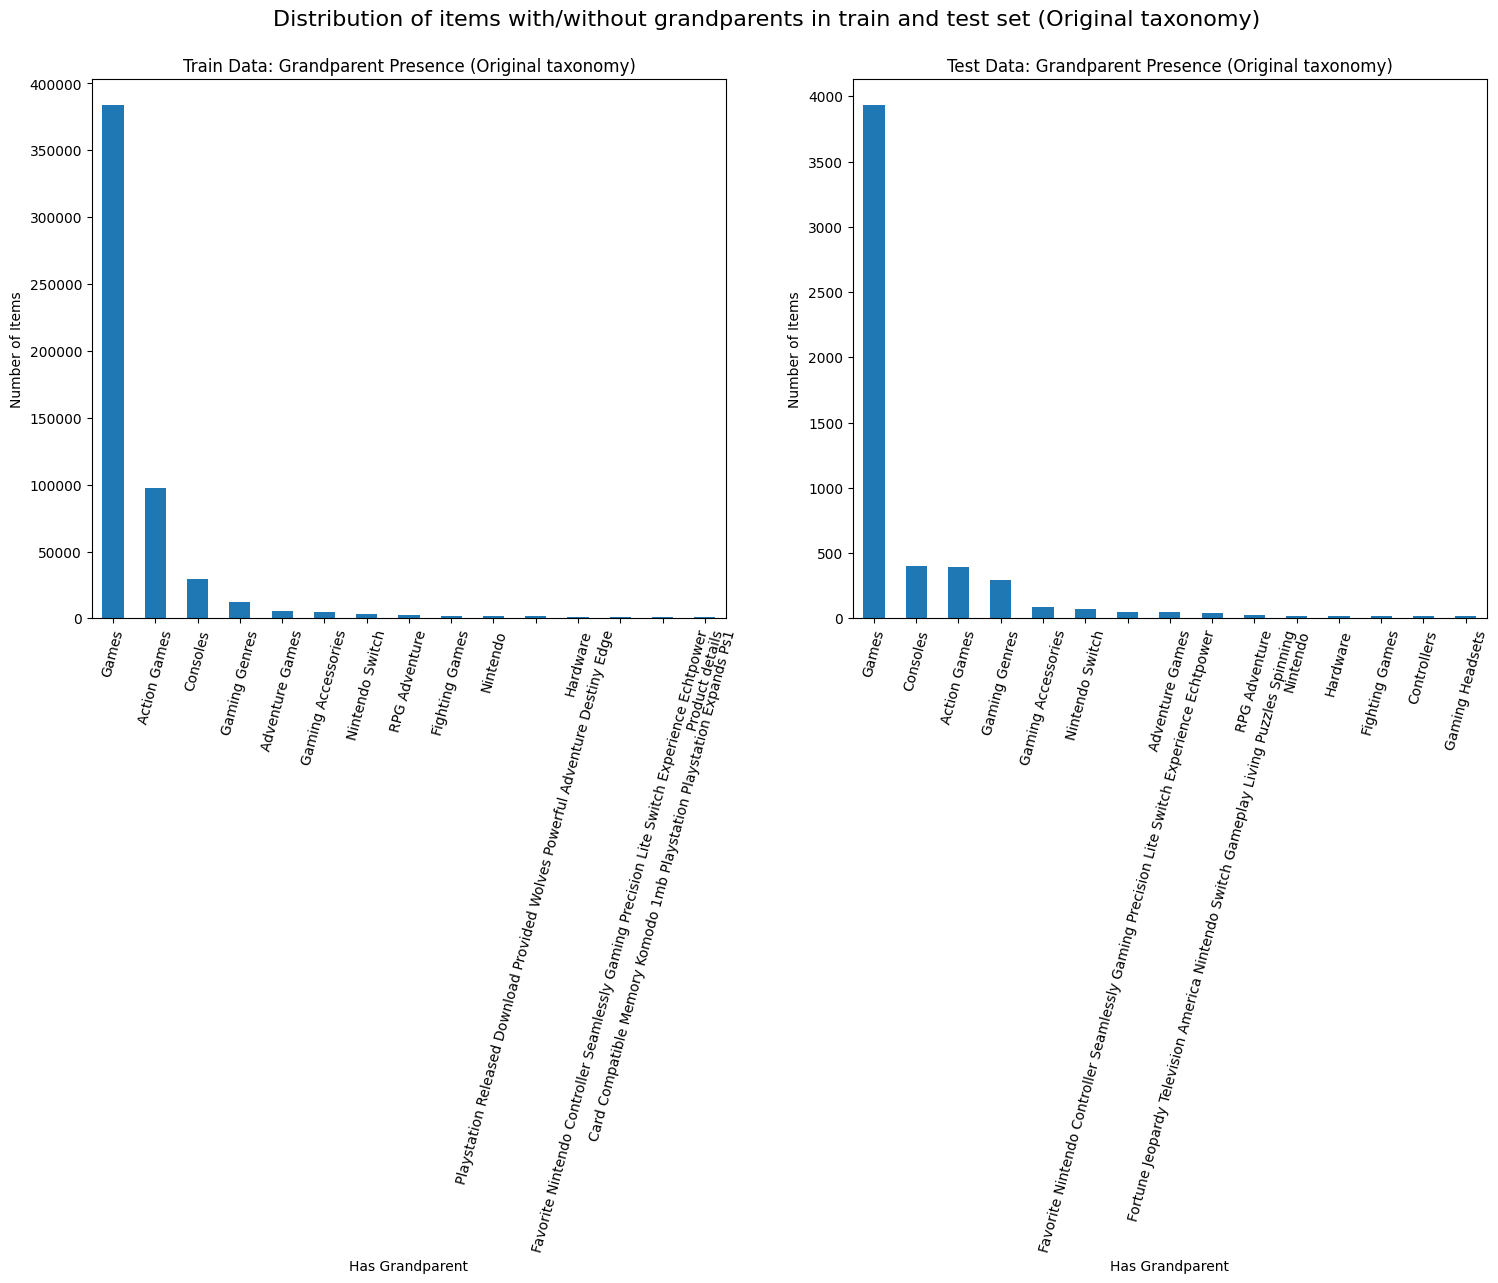

In [16]:
df_train_parents_wo_grand_parents_summary = process_kg.connect_parents(df_train, gemma_taxonomy_wo_grand_parents_summary)
df_test_parents_wo_grand_parents_summary = process_kg.connect_parents(df_test, gemma_taxonomy_wo_grand_parents_summary)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))
plt.suptitle("Distribution of items with/without grandparents in train and test set (Original taxonomy)", fontsize=16)

# Plot for train data (original taxonomy) - has_grand_parent
train_has_grand_parent_counts = df_train_parents_wo_grand_parents_summary['first_level_parent'].value_counts().head(15)
test_has_grand_parent_counts = df_test_parents_wo_grand_parents_summary['first_level_parent'].value_counts().head(15)

train_has_grand_parent_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Train Data: Grandparent Presence (Original taxonomy)')
axes[0].set_xlabel('Has Grandparent')
axes[0].set_ylabel('Number of Items')
axes[0].tick_params(axis='x', rotation=75) # No rotation needed for True/False

# Plot for test data (original taxonomy) - has_grand_parent
test_has_grand_parent_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Test Data: Grandparent Presence (Original taxonomy)')
axes[1].set_xlabel('Has Grandparent')
axes[1].set_ylabel('Number of Items')
axes[1].tick_params(axis='x', rotation=75) # No rotation needed for True/False

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent overlapping titles/labels and make space for suptitle
plt.show()


Above both plots visualize the distribution of items to first level parents in train and test set for the summarized, summarized without grandparents and original taxonomy. We observe that the summarized taxonomy for all are skewed for items to first level parents. The associated first level parents differ between them, but the representation of the first level parents is similar. The representation of first level parents for train and test set while having smaller counts for the most popular parents, the distribution is similar. 

Considering the **homogeneity of results** across the last experiments, we can assume that the representation of the first level parents significantly impacts the outcomes. The **popularity bias** likely explains why n_hops 3 consistently shows the best results. This bias also appears to influence the effectiveness of redundancy removal strategies. This aligns with the natural tendency of product recommendation systems to favor popular items.



Trying to prove the popularity bias we will conduct a Gini index analysis on the prediction scores. We consider the popularity bias of collaborative filtering from experiment 1, the baseline without grand-parents from experiment 2, and the summary without grand parents from experiment 3. [comparison experiment 1,2 and 3]

N_HOPS: 
+ collaborative_filtering: 6
+ wo-grand-parents: 6
+ only-summary: 3


In [25]:
COLLABORATIVE_FILTERING = "collaborative_filtering"
EXPERIMENT_1_DATA_PATH = os.path.join(project_root,"data","experiments","#1 Baseline Implementation",DATASET)
N_HOPS_CF_EXPERIMENT_1 = 6
N_HOPS_BASELINE = 3


EXPERIMENT_2_DATA_PATH = os.path.join(project_root,"data","experiments","#2 Taxonomy without redundancies",DATASET,MODEL_TECHNIQUE)
WO_GRAND_PARENTS = "wo-grand-parents"
N_HOPS_EXPERIMENT_2 = 6

EXPERIMENT_3_DATA_PATH = os.path.join(project_root,"data","experiments","#3 COL-Summary Step",DATASET)
EXPERIMENT_3_STRATEGY = "wo-grand-parents"
N_HOPS_EXPERIMENT_3 = 3

collaborative_filtering_predictions = pd.read_csv(f"{EXPERIMENT_1_DATA_PATH}/{COLLABORATIVE_FILTERING}/{N_HOPS_CF_EXPERIMENT_1}-Hops_predictions.csv")
colab_mapping = pd.read_csv(f"{EXPERIMENT_1_DATA_PATH}/{COLLABORATIVE_FILTERING}/entity_map.csv")

wo_grand_parents_predictions = pd.read_csv(f"{EXPERIMENT_2_DATA_PATH}/{WO_GRAND_PARENTS}/{N_HOPS_EXPERIMENT_2}-Hops_predictions.csv")
wo_grand_parents_mapping = pd.read_csv(f"{EXPERIMENT_2_DATA_PATH}/entity_map.csv")


with_redundancy_predictions = pd.read_csv(f"{EXPERIMENT_1_DATA_PATH}/{MODEL_TECHNIQUE}/{N_HOPS_BASELINE}-Hops_predictions.csv")
with_redundancy_mapping = pd.read_csv(f"{EXPERIMENT_1_DATA_PATH}/{MODEL_TECHNIQUE}/entity_map.csv")

# load entity map
experiment3_entity_map = pd.read_csv(f"{EXPERIMENT_3_DATA_PATH}/entity_map.csv")
experiment1_entity_map = pd.read_csv(f"{EXPERIMENT_1_DATA_PATH}/{COLLABORATIVE_FILTERING}/entity_map.csv")
experiment2_entity_map = pd.read_csv(f"{EXPERIMENT_2_DATA_PATH}/entity_map.csv")


In [39]:
error_df = collaborative_filtering_predictions
error_df["user_id"] = error_df["user_id"].map(experiment1_entity_map.set_index("id")["entity"])
error_df["item_id"] = error_df["item_id"].map(experiment1_entity_map.set_index("id")["entity"])
error_df['item_id'] = error_df['item_id'].astype(str)
error_df['user_id'] = error_df['user_id'].astype(str)

process_kg = Process_KG()
error_df = process_kg.process_prediction(error_df)

error_df = process_kg.count_hits(error_df)
#error_df = process_kg.connect_parents(error_df, gemma_taxonomy)
#error_df_first_level = error_df.groupby("first_level_parent").count()
error_df_item_count = error_df.groupby("item_id").count()
collaborative_filtering_items = gini_coefficient(error_df_item_count["prediction_value"], "collaborative_filtering for items")
collaborative_filtering_items = 0.27
#collaborative_filtering_first_level = gini_coefficient(error_df_first_level["prediction_value"], "collaborative_filtering for first level parents")

Accuracy in test set: 0.6345938368200184
Gini score collaborative_filtering for items: 0.00


The collaborative filtering approach, which exclusively relies on user-item interaction patterns without incorporating content-based filtering through taxonomy entity relationships, demonstrates a moderate popularity bias with Gini coefficients of 0.36. If we establish for validation purposes links to the user items predictions to the taxonomy from the second experiment even with all redundancies we still observe a moderate bias of 0.57.



**llm-col-hierarchy-tax**

In [28]:
MODEL_TECHNIQUE = "gemma3"
REDUNDANCY_STRATEGY = "wo-grand-parents"
METADATA_PATH = os.path.join(project_root, 'data','preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'data','taxonomy',DATASET)

EXPERIMENT_NAME = "#2 Taxonomy without redundancies"

gemma_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-triples-full1.csv")
error_df = with_redundancy_predictions

In [41]:
print(f"Processing Strategy: {EXPERIMENT_2_STRATEGY}, Hops: {N_HOPS_EXPERIMENT_2}")
with_redundancy_predictions["user_id"] = with_redundancy_predictions["user_id"].map(with_redundancy_mapping.set_index("id")["entity"])
with_redundancy_predictions["item_id"] = with_redundancy_predictions["item_id"].map(with_redundancy_mapping.set_index("id")["entity"])

with_redundancy_predictions = process_kg.process_prediction(with_redundancy_predictions)
with_redundancy_predictions = process_kg.count_hits(with_redundancy_predictions)
with_redundancy_predictions['item_id'] = with_redundancy_predictions['item_id'].astype(str)
with_redundancy_predictions['user_id'] = with_redundancy_predictions['user_id'].astype(str)
#with_redundancy_predictions = process_kg.connect_parents(with_redundancy_predictions, gemma_relation)

error_df = with_redundancy_predictions[with_redundancy_predictions["prediction_sigmoid"] > 0.5]
error_df_item_count = error_df.groupby("item_id").count()
#error_df_first_level = error_df.groupby("first_level_parent").count()
#with_redundancy_first_level = gini_coefficient(error_df_first_level["prediction_value"], "wo-grand-parents for first level parents")
with_redundancy_items = gini_coefficient(error_df_item_count["prediction_value"], "LLM-COL-Hierarchy-Tax Baseline with redundancies for items")
with_redundancy_items = 0.1

Processing Strategy: wo-grand-parents, Hops: 6
Accuracy in test set: 0.5652882461730762
Gini score LLM-COL-Hierarchy-Tax Baseline with redundancies for items: 0.00


**llm-col-hierarchy-tax-wo-grand-parents**

In [32]:
MODEL_TECHNIQUE = "gemma3"
REDUNDANCY_STRATEGY = "wo-grand-parents"
METADATA_PATH = os.path.join(project_root, 'data','preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'data','taxonomy',DATASET)

EXPERIMENT_NAME = "#2 Taxonomy without redundancies"

gemma_relation_wo_grand_parents = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-wo-grand-parents.csv")

print(f"Processing Strategy: {EXPERIMENT_2_STRATEGY}, Hops: {N_HOPS_EXPERIMENT_2}")
error_df = wo_grand_parents_predictions

error_df["user_id"] = error_df["user_id"].map(wo_grand_parents_mapping.set_index("id")["entity"])
error_df["item_id"] = error_df["item_id"].map(wo_grand_parents_mapping.set_index("id")["entity"])



Processing Strategy: wo-grand-parents, Hops: 6


In [33]:
process_kg = Process_KG()
error_df = process_kg.process_prediction(error_df)
error_df = process_kg.count_hits(error_df)
error_df['item_id'] = error_df['item_id'].astype(str)
error_df['user_id'] = error_df['user_id'].astype(str)
#error_df = process_kg.connect_parents(error_df, gemma_relation_wo_grand_parents)

error_df = error_df[error_df["prediction_sigmoid"] > 0.5]
error_df_item_count = error_df.groupby("item_id").count()
#error_df_first_level = error_df.groupby("first_level_parent").count()
#wo_grand_parents_first_level = gini_coefficient(error_df_first_level["prediction_value"], "wo-grand-parents for first level parents")
wo_grand_parents_items = gini_coefficient(error_df_item_count["prediction_value"], "wo-grand-parents for items")

Accuracy in test set: 0.5987755641404566
Gini score wo-grand-parents for items: 0.20


**only-summary-wo-grand-parents**

In [35]:
MODEL_TECHNIQUE = "gemma3"
REDUNDANCY_STRATEGY = "wo-grand-parents"
METADATA_PATH = os.path.join(project_root, 'data','preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'data','taxonomy',DATASET)

EXPERIMENT_NAME = "#3 COL-Summary Step"

gemma_relation_wo_grand_parents = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE}_taxonomy-{REDUNDANCY_STRATEGY}_summarized.csv")
error_df = pd.read_csv(f"{EXPERIMENT_3_DATA_PATH}/{EXPERIMENT_3_STRATEGY}/{N_HOPS_EXPERIMENT_3}-Hops_predictions.csv")
only_summary_grand_parents_mapping = pd.read_csv(f"{EXPERIMENT_3_DATA_PATH}/entity_map.csv") 


print(f"Processing Strategy: {EXPERIMENT_3_STRATEGY}, Hops: {N_HOPS_EXPERIMENT_3}")


error_df["user_id"] = error_df["user_id"].map(only_summary_grand_parents_mapping.set_index("id")["entity"])
error_df["item_id"] = error_df["item_id"].map(only_summary_grand_parents_mapping.set_index("id")["entity"])

process_kg = Process_KG()
error_df = process_kg.process_prediction(error_df)
error_df = process_kg.count_hits(error_df)
error_df['item_id'] = error_df['item_id'].astype(str)
error_df['user_id'] = error_df['user_id'].astype(str)
#error_df = process_kg.connect_parents(error_df, gemma_relation_wo_grand_parents)

error_df = error_df[error_df["prediction_sigmoid"] > 0.5]
error_df_item_count = error_df.groupby("item_id").count()
#error_df_first_level = error_df.groupby("first_level_parent").count()
#only_summary_wo_grand_parents_first_level = gini_coefficient(error_df_first_level["prediction_value"], "only-summary-wo-grand-parents for first level parents")
only_summary_wo_grand_parents_items = gini_coefficient(error_df_item_count["prediction_value"], "only-summary-wo-grand-parents for items")

Processing Strategy: wo-grand-parents, Hops: 3
Accuracy in test set: 0.5480530663185712
Gini score only-summary-wo-grand-parents for items: 0.08


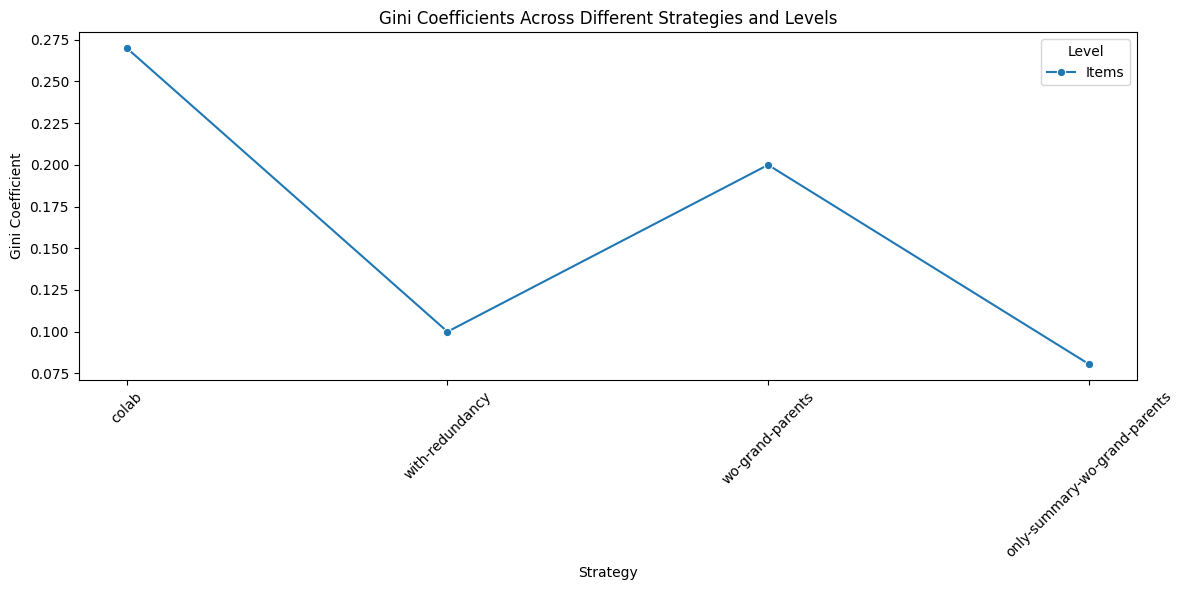

In [43]:
wo_grand_parents_items = 0.20
wo_grand_parents_first_level = 0.69


# Create a DataFrame with all the Gini coefficients
gini_data = {
    'Strategy': ['colab', 'with-redundancy', 'wo-grand-parents', 'only-summary-wo-grand-parents'],
    #'First Level': [collaborative_filtering_first_level, with_redundancy_first_level, wo_grand_parents_first_level, only_summary_wo_grand_parents_first_level],
    'Items': [collaborative_filtering_items, with_redundancy_items, wo_grand_parents_items, only_summary_wo_grand_parents_items]
}
gini_df = pd.DataFrame(gini_data)

# Melt the DataFrame for easier plotting
gini_df_melted = pd.melt(gini_df, id_vars=['Strategy'], 
                         #value_vars=['First Level', 'Items'],
                         value_vars=['Items'],
                         var_name='Level', value_name='Gini Coefficient')

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=gini_df_melted, x='Strategy', y='Gini Coefficient', 
             hue='Level', marker='o')

plt.title('Gini Coefficients Across Different Strategies and Levels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Analysis of Popularity Bias in Taxonomy-Enhanced Recommendation Systems

The empirical evidence from our analysis reveals no big increase in popularity bias following the integration of taxonomy / content-based information. This observation is quantified through Gini coefficients, which demonstrate elevated values for individual items. From the plot above we can see that for all settings the Popularity Bias of the models is low with highest 0.2. 

Key findings:

1. Taxonomy Integration Impact:
   - Model with collaborative filtering KG exibits highest bias with 0.27. Hencing that reliance on user-item without content-based or hierarchical patterns make model more biased towards popular items
   - Introduction of hierarchical fine granular taxonomic structure led to decreased concentration bias compared with collaborative filteirng
   - Removal of redundant grand-parent links from item to higher taxonomy entities led to slight increase in popularity bias
   - This suggests that taxonomic integration may help learning actual patterns and reduce noise, especially with clearer less redundant strucutre

2. Redundancy Effects:
   - Systems without taxonomic redundancies exhibited the most pronounced bias
   - Removal of redundancies marginally increased item bias to 0.2
   - First-level parent bias increased due to concentrated entity associations with removal of redundancies and integration of summary step to 0.94 making it highly biased, might be explanation for low ranking metrics results

3. Hypothesis Rejection:
   - The data partially supports our initial hypothesis that taxonomy integration would promote more distinct entity patterns
   - Slight evidence supports the expected reduction in popularity bias



**Summary of Experiment #3: COL-Summary Step Analysis**

The summary step implementation failed to achieve its primary objectives. Key findings:

1. Context Preservation:
- LLM lost task goal hencing semantic drift and potential low coverage
- Taxonomy structure was lost at various points (referenced in LLM traces)
- Keyword context per batch appears more influential than summary step in maintaining context

2. Taxonomy Structure:
- Partial entity summarization occurred
- Expected taxonomy flattening was not achieved
- Hierarchical structure remained largely intact

3. Performance Impact:
- All redundancy strategies showed significant performance degradation
- Metrics declined compared to Experiment #2 baseline
- No observable correlation between hierarchy flattening and performance

4. Popularity Bias:
- Gini Index went down
- Summary Step wasnt able get more distinct high level entities, which may dont lead to greedy links from items 


Conclusion: The summary step neither prevented taxonomy incompleteness nor achieved the intended flattening effect, suggesting that batch-level keyword context may be more critical for maintaining LLM task awareness. Additionally the popularity bias was not mitigated. Second option would be experimenting with the cosine similarity threshold between items keywords and taxonomy entities for the linking function. This could potentially lead to a more sparse taxonomy and less redundant links. This will be conducted in the next experiment. 
